# Archived time-series notes

This is older exploratory work kept for reference.


In [64]:
import sklearn

In [65]:
from sklearn.model_selection import TimeSeriesSplit

In [71]:
series = np.random.choice([-1,1],100,replace = True).cumsum()

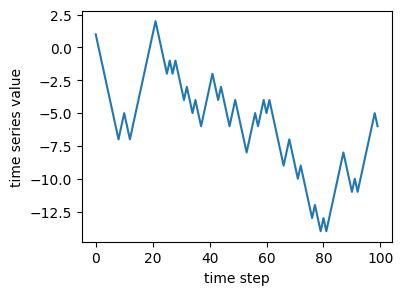

In [72]:
plt.figure(figsize = (4,3))
plt.plot(range(100), series)
plt.xlabel("time step")
plt.ylabel("time series value")

plt.show()

In [73]:
kfold = TimeSeriesSplit(n_splits = 5, test_size = 14)

In [80]:
for train_index, test_index in kfold.split(series):
    print("train index:", train_index)
    print("test_index:", test_index)
    print("-"*100)


train index: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]
test_index: [30 31 32 33 34 35 36 37 38 39 40 41 42 43]
----------------------------------------------------------------------------------------------------
train index: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43]
test_index: [44 45 46 47 48 49 50 51 52 53 54 55 56 57]
----------------------------------------------------------------------------------------------------
train index: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57]
test_index: [58 59 60 61 62 63 64 65 66 67 68 69 70 71]
----------------------------------------------------------------------------------------------------
train index: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 2

In [82]:
from datetime import datetime, timedelta
from seaborn import set_style
from sklearn.metrics import mean_squared_error

set_style("whitegrid")

three data sets

In [84]:
no_trend = 5 + np.random.normal(size = 100)
trend = 5 + 2*np.arange(100) + 10*np.random.normal(size = 100)
seasonality = 5 + 2*np.sin(np.arange(100) + 2*np.pi/12) + np.random.normal(size = 100)

In [86]:
no_trend_train = no_trend[:80]
no_trend_test = no_trend[80:]

trend_train = trend[:80]
trend_test = trend[80:]

seasonality_train = seasonality[:80]
seasonality_test = seasonality[80:]

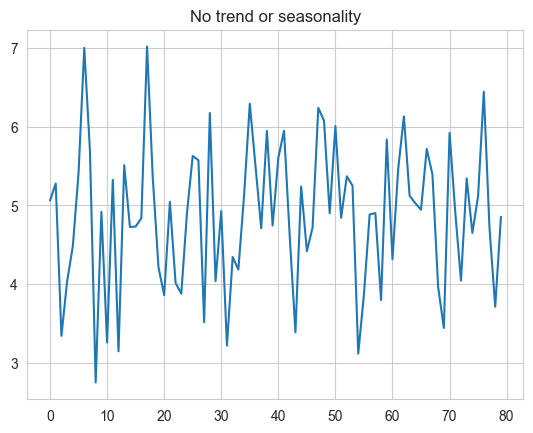

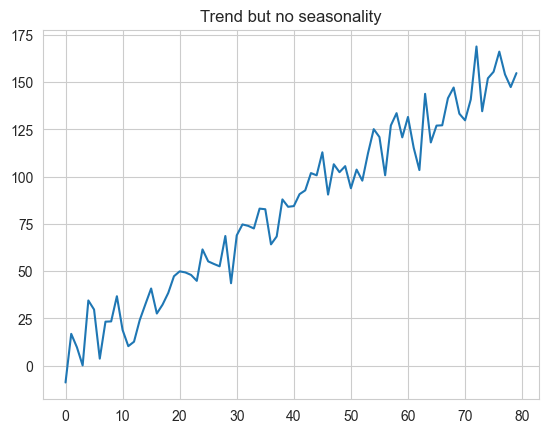

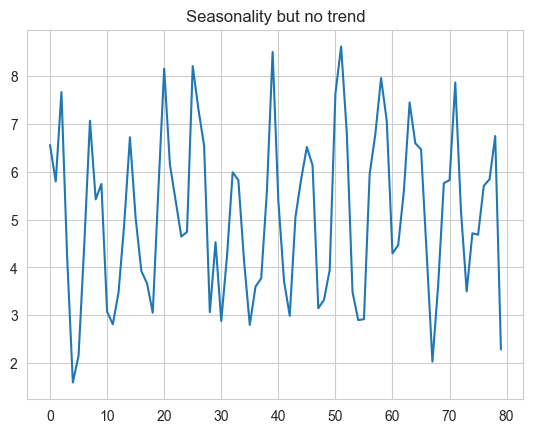

In [88]:
plt.plot(np.arange(80), no_trend_train)
plt.title("No trend or seasonality")
plt.show()

plt.plot(np.arange(80), trend_train)
plt.title("Trend but no seasonality")
plt.show()

plt.plot(np.arange(80), seasonality_train)
plt.title("Seasonality but no trend")
plt.show()

In [89]:
 average_forecast = no_trend_train.mean() * np.ones(20)

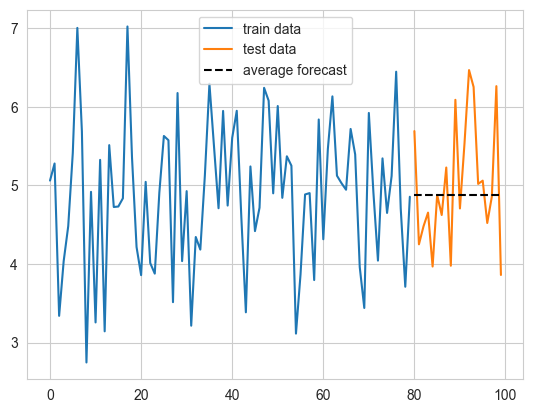

In [94]:
plt.plot(np.arange(80),no_trend_train, label = 'train data')
plt.plot(np.arange(80,100), no_trend_test, label = 'test data')
plt.plot(np.arange(80,100), average_forecast, '--k', label = 'average forecast')
plt.legend()
plt.show()

linear trend, no seasonality

In [100]:
from sklearn.linear_model import LinearRegression

train_times = np.arange(len(trend_train)).reshape(-1,1)
forecast_times = np.arange(80,100).reshape(-1,1)

linear_trend_reg = LinearRegression()
linear_trend_reg.fit(train_times, trend_train)
linear_trend_forecast = linear_trend_reg.predict(forecast_times)

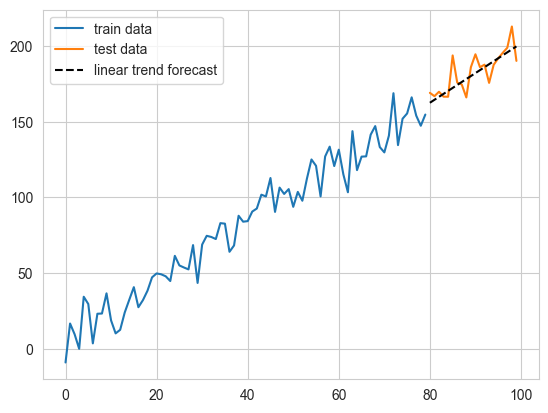

In [101]:
plt.plot(np.arange(80), trend_train, label = 'train data')
plt.plot(np.arange(80,100), trend_test, label = 'test data')
plt.plot(np.arange(80,100), linear_trend_forecast, '--k', label = 'linear trend forecast')
plt.legend()
plt.show()

In [103]:
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression

linear_trend_reg = LinearRegression()
linear_trend_reg.fit(np.arange(len(trend_train)).reshape(-1,1), trend_train)
linear_trend_train_preds = linear_trend_reg.predict(np.arange(len(trend_train)).reshape(-1,1))
linear_trend_std = np.sqrt(mean_squared_error(trend_train, linear_trend_train_preds))
linear_trend_forecast = linear_trend_reg.predict(np.arange(80,100).reshape(-1,1))

slope = (trend_train[-1] - trend_train[0])/len(trend_train)
intercept = trend_train[0]
drift_model = np.vectorize(lambda t: intercept + slope*t)
drift_forecast = drift_model(np.arange(80,100))
drift_model_std = np.sqrt(np.mean((np.diff(trend_train) - slope)**2))

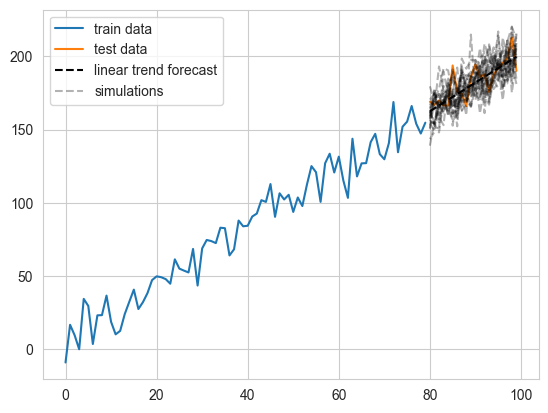

In [106]:
plt.plot(np.arange(80), trend_train, label = 'train data')
plt.plot(np.arange(80,100), trend_test, label = 'test data')
plt.plot(np.arange(80,100), linear_trend_forecast, '--k', label = 'linear trend forecast')

for i in range(20):
    epsilons = np.random.normal(loc = 0, scale = linear_trend_std, size = 20)
    simulated_path = linear_trend_forecast + epsilons
    label = 'simulations' if i == 0 else None # only label first for legend
    plt.plot(np.arange(80,100), simulated_path, '--k', alpha = 0.3, label = label)

plt.legend()
plt.show()